# Presentation Visuals — Bagmati Forest-Fire Susceptibility

This notebook regenerates every figure used in the project defence from the real
dataset (`forest_fire_dataset_100m.parquet`). It **loads the pre-trained models**
from `outputs/models/` (produced by `model_training.ipynb` and
`pytorch_train.ipynb`), evaluates them on the **spatial block split**, and saves
PNGs to `outputs/figures/`:

1. Class imbalance
2. Study-area fire distribution
3. Model comparison (AUC-PR / AUC-ROC)
4. ROC curves   5. Precision–Recall curves
6. **Confusion matrices** (one per model, at the F1-optimal threshold)
7. Feature importance (XGBoost gain)
8. **Province-wide susceptibility map** (best model applied to all flammable cells)

Everything is reproducible (`RANDOM_STATE = 42`).

## 1 · Setup

In [1]:
import os
# macOS: torch, xgboost and lightgbm each bundle their own OpenMP (libomp).
# Loading all of them in one kernel otherwise segfaults. Set BEFORE importing torch.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import warnings, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT   = Path("/Users/bikinshrestha/Personal/masters/data_analytics/sem_project")
FIG    = ROOT / "outputs" / "figures"
MODELS = ROOT / "outputs" / "models"
FIG.mkdir(parents=True, exist_ok=True)
print("figures ->", FIG)
print("models  ->", MODELS)

figures -> /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/figures
models  -> /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/models


## 2 · Load, spatial split, preprocess (same recipe as `model_training.ipynb`)

In [2]:
df = pd.read_parquet(ROOT / "data/processed/forest_fire_dataset_100m.parquet")
df = df[df.is_flammable == 1].reset_index(drop=True)

TOPO    = ["elevation_m","slope_deg","aspect_sin","aspect_cos","tri","twi","solar_radiation"]
CLIMATE = ["temp_max_mean_c","wind_max_mean_kmh","precip_fire_season_mm","drought_factor","fwi_proxy","consec_dry_days_max"]
VEG     = ["ndvi_fire_season","ndvi_premonsoon","ndvi_anomaly","evi","nbr","ndwi","lst_fire_season_mean_c"]
HUMAN   = ["log_dist_to_road","log_dist_to_settlement","log_dist_to_forest_edge","log_dist_to_cropland","log_population_density"]
FEATURES = TOPO + CLIMATE + VEG + HUMAN + ["lulc_code"]
TARGET = "fire_occurred"

BLOCK_DEG = 0.1
df["block_id"] = (np.floor(df.lat/BLOCK_DEG).astype(int).astype(str) + "_" +
                  np.floor(df.lon/BLOCK_DEG).astype(int).astype(str))
blocks = df.block_id.unique()
rng = np.random.RandomState(RANDOM_STATE)
test_blocks = set(rng.permutation(blocks)[:int(0.20*len(blocks))])
test_mask = df.block_id.isin(test_blocks).values
train_mask = ~test_mask

X = df[FEATURES]; y = df[TARGET].astype(int).values
X_tr, y_tr = X[train_mask], y[train_mask]
X_te, y_te = X[test_mask],  y[test_mask]

neg_pos = (y_tr==0).sum() / (y_tr==1).sum()
assert len(y_tr) == 1_680_339 and len(y_te) == 443_309, "split drift vs model_training.ipynb!"
print(f"train {len(y_tr):,} ({y_tr.sum()} fires) | test {len(y_te):,} ({y_te.sum()} fires) | neg/pos={neg_pos:.0f}")

train 1,680,339 (3404 fires) | test 443,309 (727 fires) | neg/pos=493


## 3 · Evaluation helper

In [3]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, roc_curve, confusion_matrix)
results, probs = {}, {}

def evaluate(name, y_true, y_prob):
    ap  = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2*prec*rec/(prec+rec+1e-9)
    bi = int(np.nanargmax(f1)); bt = float(thr[min(bi, len(thr)-1)])
    tn, fp, fn, tp = confusion_matrix(y_true, (y_prob>=bt).astype(int)).ravel()
    results[name] = {"AUC_PR":float(ap),"AUC_ROC":float(roc),"best_F1":float(f1[bi]),
                     "thr":bt,"TN":int(tn),"FP":int(fp),"FN":int(fn),"TP":int(tp)}
    probs[name] = y_prob
    print(f"{name:16s} AUC-PR={ap:.4f} AUC-ROC={roc:.3f} F1={f1[bi]:.3f} thr={bt:.3f}")
    return results[name]

## 4 · Load the saved tree / linear model family

These come from `model_training.ipynb` via `outputs/models/sklearn_models.joblib`
(same `RANDOM_STATE=42`, same 80/20 spatial block split, so the hold-out matches).
The bundle carries the fitted **imputer** and **scaler**, so no refitting is needed.

> Note: **BRT** (HistGradientBoosting) was never serialized to the bundle, so it is
> omitted here — the comparison covers the five persisted sklearn models plus the
> PyTorch MLP loaded in the next section.

In [4]:
import joblib

bundle     = joblib.load(MODELS / "sklearn_models.joblib")
assert bundle["features"] == FEATURES, "feature-order drift vs training!"
sk_models  = bundle["models"]
model_kind = bundle["model_kind"]
imp = bundle["imputer"]             
sc  = bundle["scaler"]               
Xte_imp = imp.transform(X_te)
Xte_sc  = sc.transform(Xte_imp).astype(np.float32)

DISPLAY_NAMES = {
    "LogisticReg":  "LogReg",
    "RandomForest": "RandomForest",
    "XGBoost":      "XGBoost",
    "LightGBM":     "LightGBM",
    "MLP":          "MLP (sklearn)",
}
for key, mdl in sk_models.items():
    mat = Xte_sc if model_kind[key] == "sc" else Xte_imp
    evaluate(DISPLAY_NAMES[key], y_te, mdl.predict_proba(mat)[:, 1])

# Convenience handles reused by the feature-importance and susceptibility-map cells.
lr    = sk_models["LogisticReg"]
rf    = sk_models["RandomForest"]
xgbc  = sk_models["XGBoost"]
lgbc  = sk_models["LightGBM"]
skmlp = sk_models["MLP"]

LogReg           AUC-PR=0.0052 AUC-ROC=0.729 F1=0.021 thr=0.798
RandomForest     AUC-PR=0.0073 AUC-ROC=0.737 F1=0.036 thr=0.753
XGBoost          AUC-PR=0.0082 AUC-ROC=0.736 F1=0.035 thr=0.852
LightGBM         AUC-PR=0.0035 AUC-ROC=0.600 F1=0.013 thr=1.000
MLP (sklearn)    AUC-PR=0.0085 AUC-ROC=0.729 F1=0.034 thr=0.459


## 5 · Load the PyTorch MLP (from `pytorch_train.ipynb`)

The weights live in `outputs/models/pytorch_mlp_state.pt` and ship with their own
imputer + scaler in `pytorch_mlp_preprocess.joblib` (the PyTorch model trained on a
different 70/15/15 split, so it must use its own preprocessing for inference).

In [5]:
import torch, torch.nn as nn
torch.manual_seed(RANDOM_STATE)
DEV = torch.device("mps" if torch.backends.mps.is_available() else
                   "cuda" if torch.cuda.is_available() else "cpu")

STATE_PT      = MODELS / "pytorch_mlp_state.pt"
PREPROCESS_PT = MODELS / "pytorch_mlp_preprocess.joblib"
assert STATE_PT.exists() and PREPROCESS_PT.exists(), (
    "Missing PyTorch artifacts. Run pytorch_train.ipynb section 13 first to create "
    f"{STATE_PT.name} and {PREPROCESS_PT.name} under {MODELS}."
)

# Must match pytorch_train.ipynb exactly: saved state_dict keys are prefixed
# `net.` (e.g. net.0.weight), so the layers have to live inside a `net` attribute.
class FireMLP(nn.Module):
    def __init__(self, n_features, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

pp  = joblib.load(PREPROCESS_PT)        # its own imputer + scaler (pytorch split)
assert pp["features"] == FEATURES, "PyTorch feature-order drift vs training!"
net = FireMLP(pp["n_features"]).to(DEV)
net.load_state_dict(torch.load(STATE_PT, map_location=DEV))
net.eval()

@torch.no_grad()
def ppredict(model, X_np, chunk=200_000):
    """Sigmoid probabilities for a numpy feature matrix, scored in MPS-safe chunks."""
    out = np.empty(len(X_np), dtype="float32")
    for i in range(0, len(X_np), chunk):
        xb = torch.from_numpy(X_np[i:i+chunk]).to(DEV)
        out[i:i+chunk] = torch.sigmoid(model(xb)).cpu().numpy().ravel()
    return out

Xte_pt = pp["scaler"].transform(pp["imputer"].transform(X_te)).astype(np.float32)
evaluate("MLP (PyTorch)", y_te, ppredict(net, Xte_pt))
print("loaded PyTorch MLP:", sum(p.numel() for p in net.parameters()), "params")

MLP (PyTorch)    AUC-PR=0.0066 AUC-ROC=0.722 F1=0.034 thr=0.430
loaded PyTorch MLP: 12161 params


## 6 · Figure — class imbalance

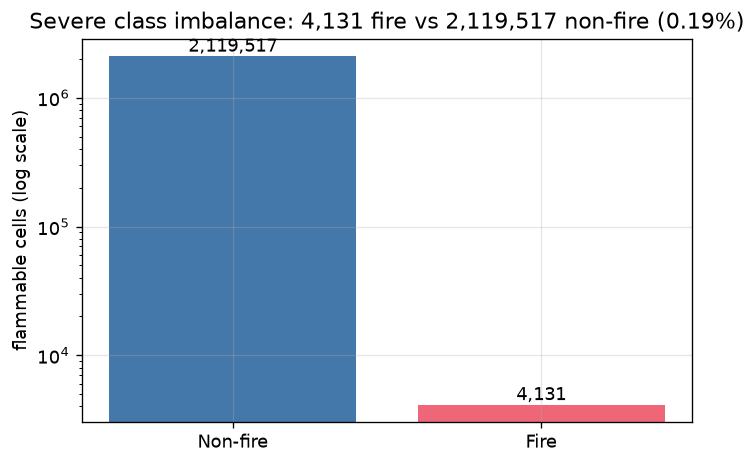

In [6]:
n0, n1 = int((y==0).sum()), int((y==1).sum())
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Non-fire","Fire"], [n0, n1], color=["#4477AA","#EE6677"])
ax.set_yscale("log")
ax.set_ylabel("flammable cells (log scale)")
ax.set_title(f"Severe class imbalance: {n1:,} fire vs {n0:,} non-fire ({n1/(n0+n1):.2%})")
for i,v in enumerate([n0,n1]): 
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG/"01_class_imbalance.png")
plt.show()

## 7 · Figure — study-area fire distribution

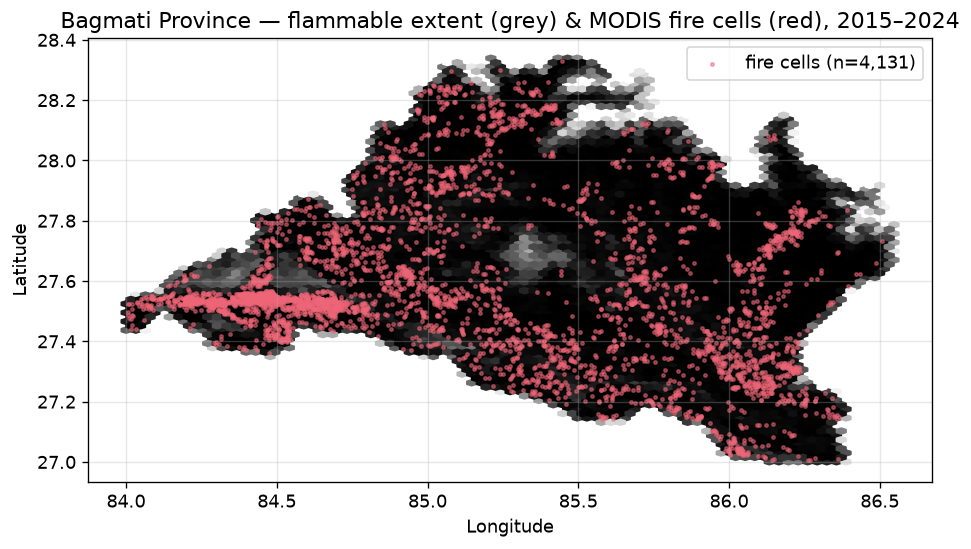

In [7]:
fires = df[df.fire_occurred==1]
fig, ax = plt.subplots(figsize=(8,5))
hb = ax.hexbin(df.lon, df.lat, gridsize=80, cmap="Greys", bins="log", mincnt=1)
ax.scatter(fires.lon, fires.lat, s=4, c="#EE6677", alpha=0.5, label=f"fire cells (n={len(fires):,})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bagmati Province — flammable extent (grey) & MODIS fire cells (red), 2015–2024")
ax.legend(loc="upper right"); ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.savefig(FIG/"02_study_area_fires.png")
plt.show()

## 8 · Figure — model comparison (AUC-PR / AUC-ROC)

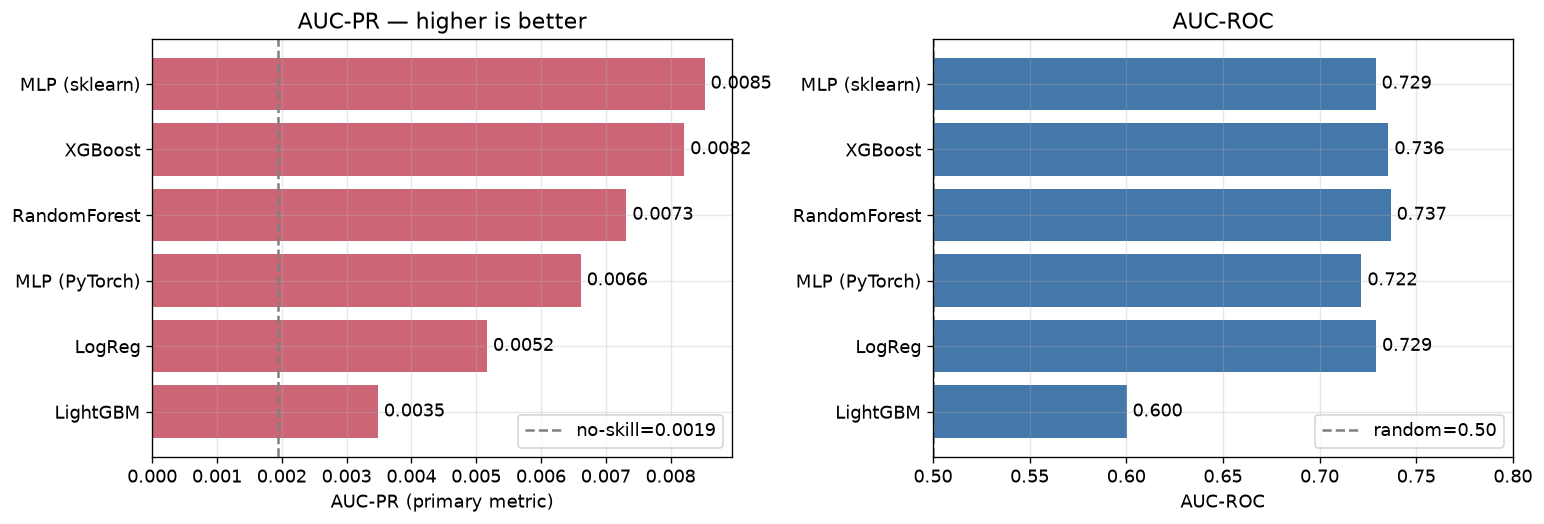

In [8]:
order = sorted(results, key=lambda k: results[k]["AUC_PR"], reverse=True)
ap  = [results[k]["AUC_PR"] for k in order]
roc = [results[k]["AUC_ROC"] for k in order]
x = np.arange(len(order))
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
ax[0].barh(x, ap, color="#CC6677"); ax[0].set_yticks(x); ax[0].set_yticklabels(order)
ax[0].invert_yaxis(); ax[0].set_xlabel("AUC-PR (primary metric)")
ax[0].axvline(y.mean(), ls="--", c="grey", label=f"no-skill={y.mean():.4f}")
ax[0].legend()
for i,v in enumerate(ap): 
    ax[0].text(v, i, f" {v:.4f}", va="center")
ax[0].set_title("AUC-PR — higher is better")


ax[1].barh(x, roc, color="#4477AA")
ax[1].set_yticks(x)
ax[1].set_yticklabels(order)
ax[1].invert_yaxis()
ax[1].set_xlim(0.5,0.8)
ax[1].set_xlabel("AUC-ROC")
ax[1].axvline(0.5, ls="--", c="grey", label="random=0.50")
ax[1].legend()
for i,v in enumerate(roc): 
    ax[1].text(v, i, f" {v:.3f}", va="center")
ax[1].set_title("AUC-ROC")


plt.tight_layout()
plt.savefig(FIG/"03_model_comparison.png")
plt.show()

## 9 · Figure — ROC curves

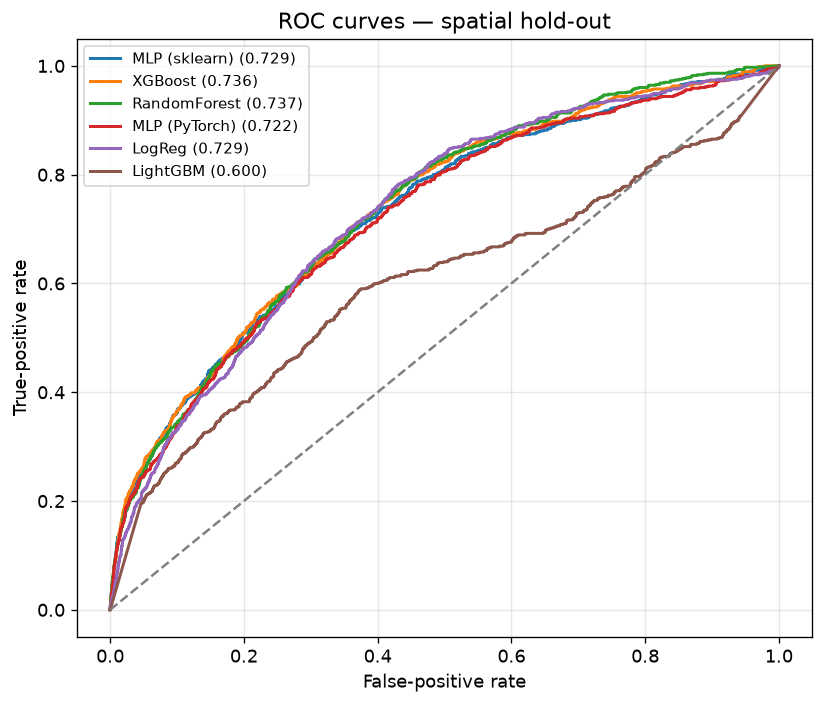

In [9]:
fig, ax = plt.subplots(figsize=(7,6))
for k in order:
    fpr, tpr, _ = roc_curve(y_te, probs[k])
    ax.plot(fpr, tpr, lw=1.8, label=f"{k} ({results[k]['AUC_ROC']:.3f})")
ax.plot([0,1],[0,1], ls="--", c="grey")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title("ROC curves — spatial hold-out")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG/"04_roc_curves.png")
plt.show()

## 10 · Figure — Precision–Recall curves

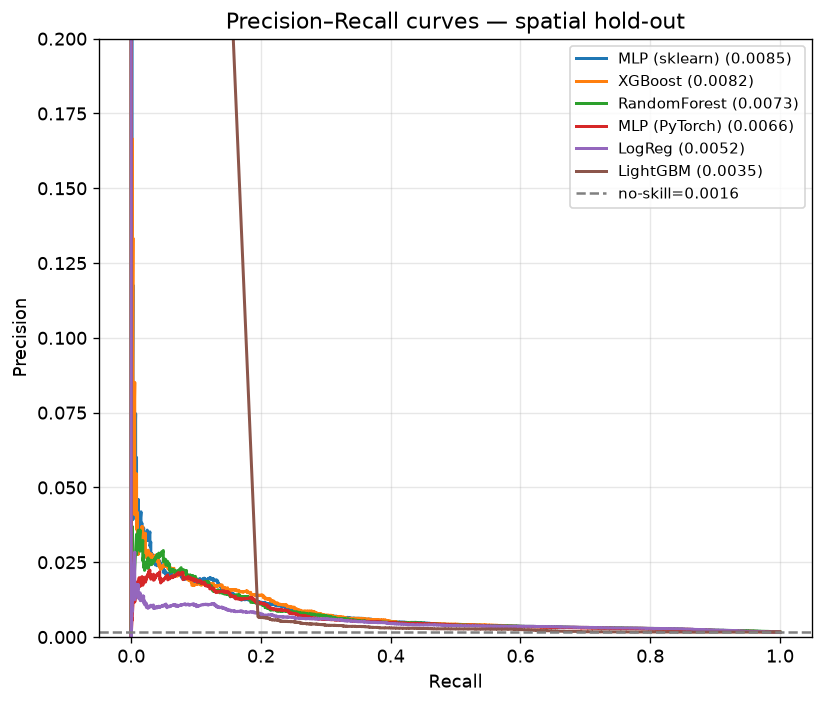

In [10]:
fig, ax = plt.subplots(figsize=(7,6))
for k in order:
    prec, rec, _ = precision_recall_curve(y_te, probs[k])
    ax.plot(rec, prec, lw=1.8, label=f"{k} ({results[k]['AUC_PR']:.4f})")
ax.axhline(y_te.mean(), ls="--", c="grey", label=f"no-skill={y_te.mean():.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 0.2)
ax.set_title("Precision–Recall curves — spatial hold-out")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG/"05_pr_curves.png"); plt.show()

## 11 · Figure — confusion matrices (F1-optimal threshold)

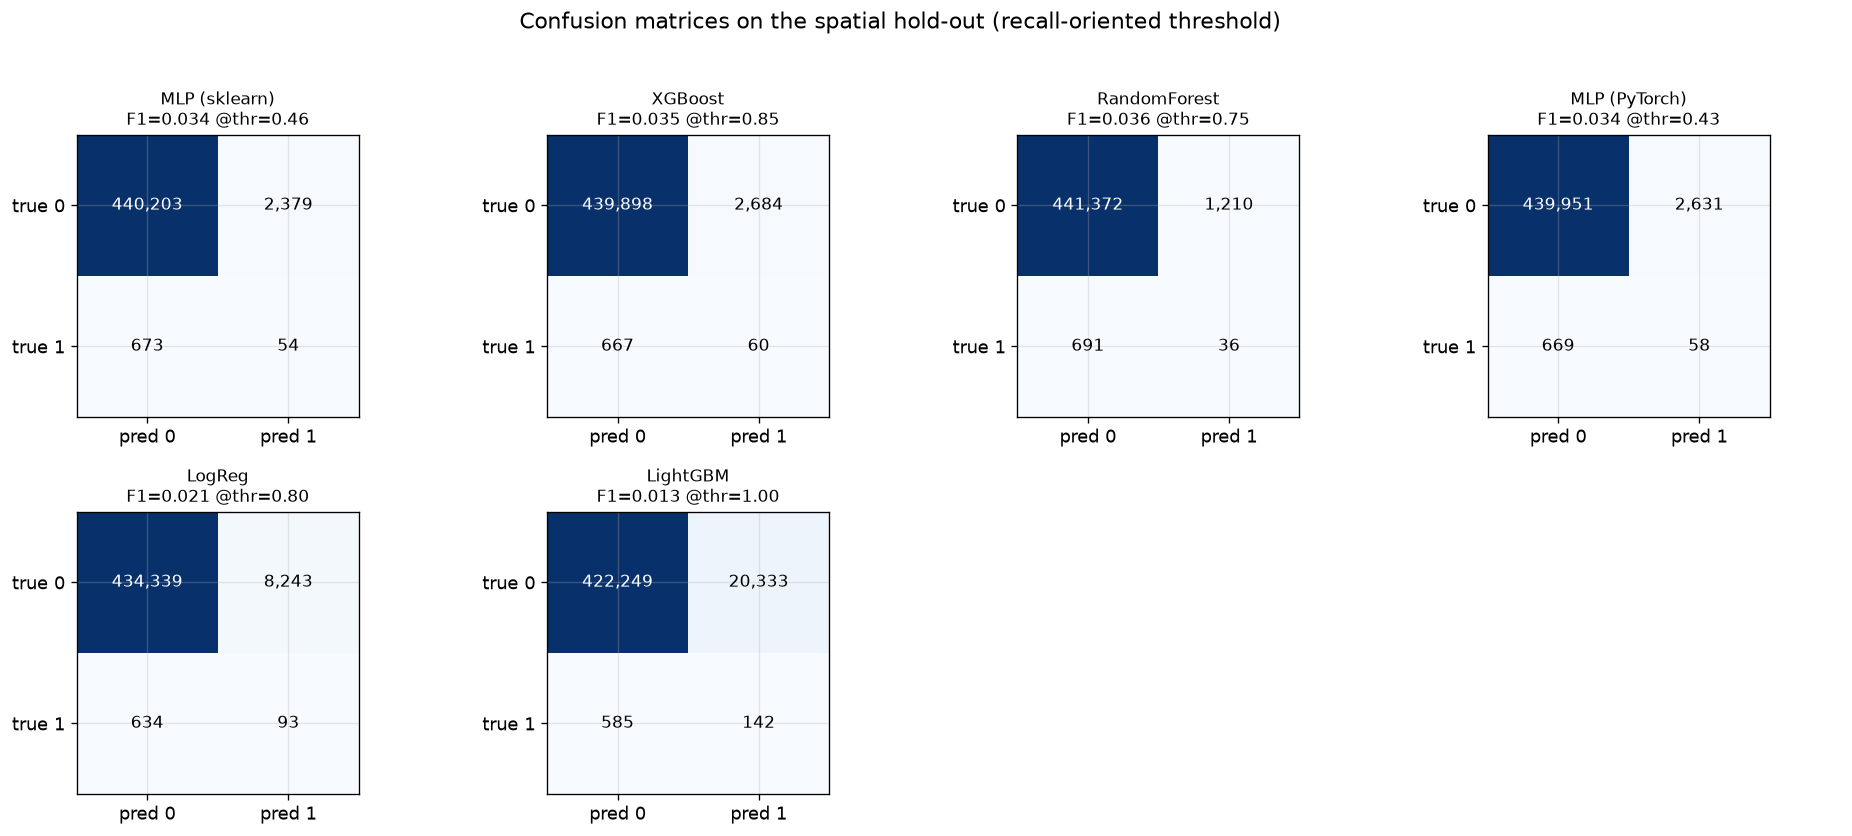

In [11]:
n = len(order); cols = 4; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.4*rows))
axes = np.atleast_1d(axes).ravel()
for ax_, k in zip(axes, order):
    r = results[k]; cm = np.array([[r["TN"], r["FP"]],[r["FN"], r["TP"]]])
    im = ax_.imshow(cm, cmap="Blues")
    ax_.set_title(f"{k}\nF1={r['best_F1']:.3f} @thr={r['thr']:.2f}", fontsize=10)
    ax_.set_xticks([0,1])
    ax_.set_xticklabels(["pred 0","pred 1"])
    ax_.set_yticks([0,1])
    ax_.set_yticklabels(["true 0","true 1"])
    for (i,j),v in np.ndenumerate(cm):
        ax_.text(j, i, f"{v:,}", ha="center", va="center",
                 color="white" if v>cm.max()/2 else "black", fontsize=10)
for ax_ in axes[n:]: ax_.axis("off")
fig.suptitle("Confusion matrices on the spatial hold-out (recall-oriented threshold)", y=1.02)
plt.tight_layout()
plt.savefig(FIG/"06_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 12 · Figure — feature importance (XGBoost gain)

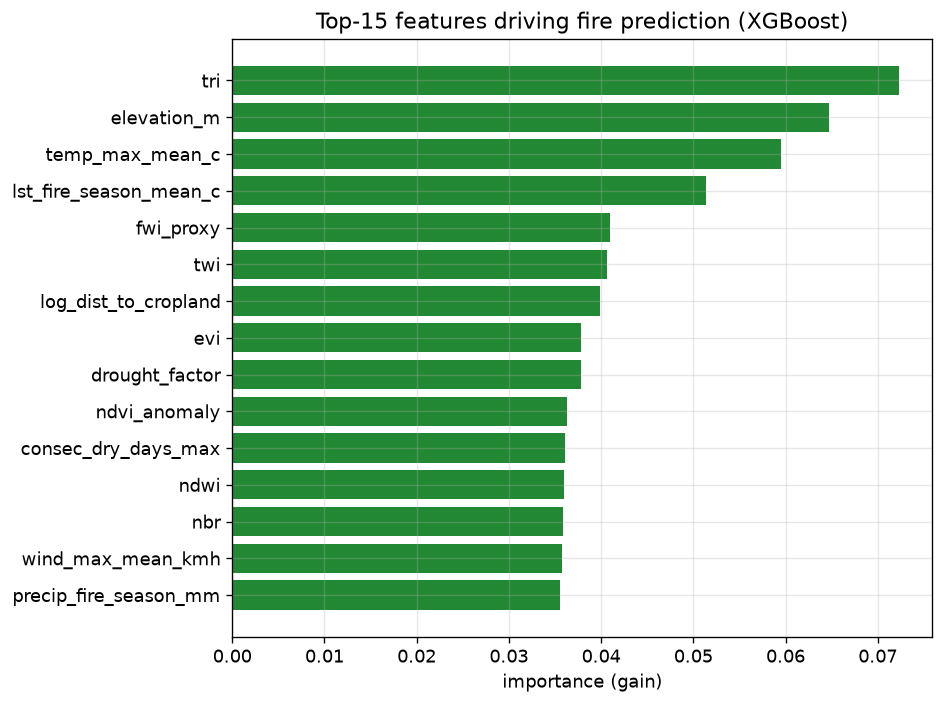

In [12]:
imp_vals = xgbc.feature_importances_
idx = np.argsort(imp_vals)[::-1][:15][::-1]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(range(len(idx)), imp_vals[idx], color="#228833")
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([FEATURES[i] for i in idx])
ax.set_xlabel("importance (gain)")
ax.set_title("Top-15 features driving fire prediction (XGBoost)")
plt.tight_layout()
plt.savefig(FIG/"07_feature_importance.png")
plt.show()

## 13 · Figure — province-wide susceptibility map (best model)

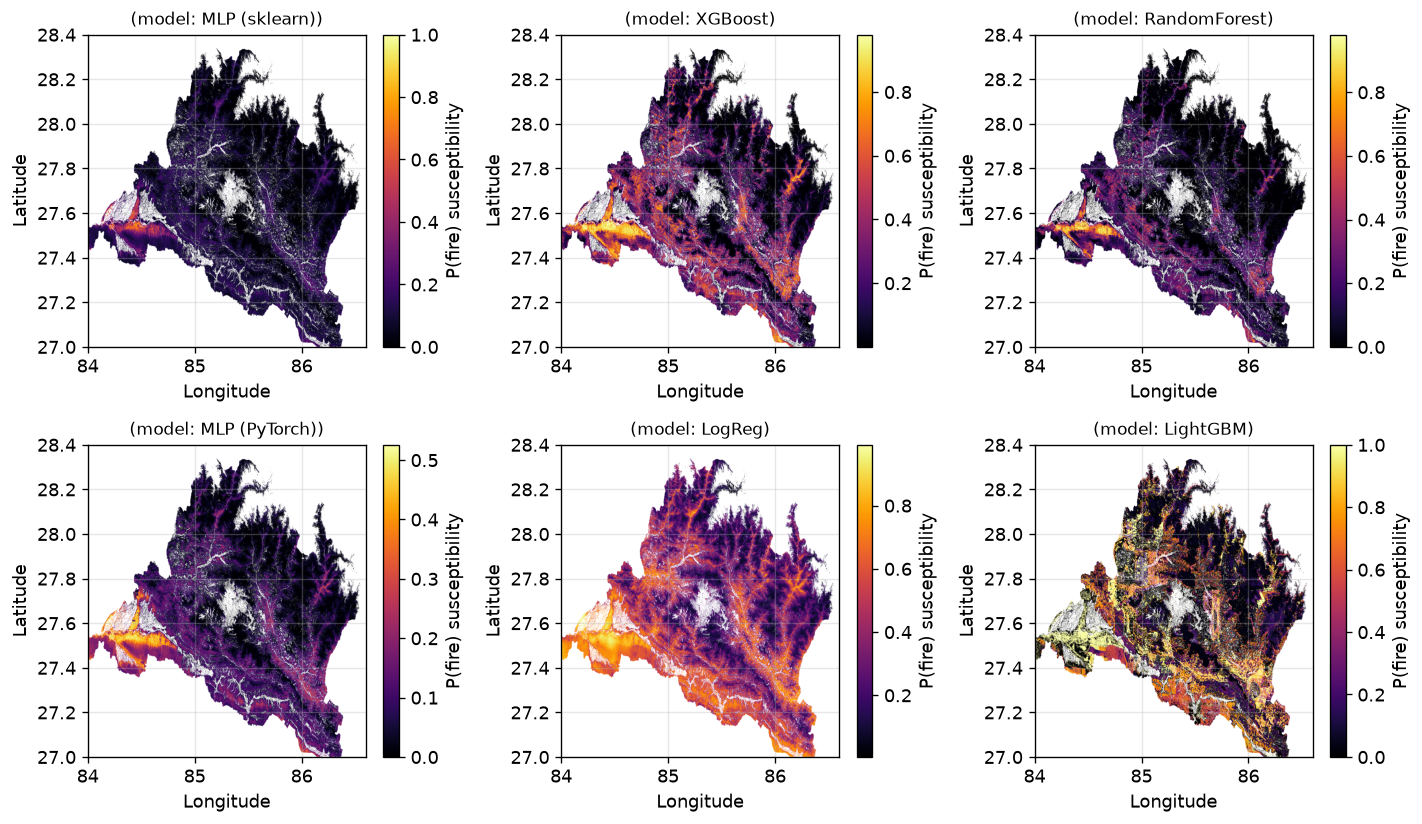

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
X_all_imp = imp.transform(X)  # Only compute once if safe to do so

# Map best names to classifier objects
clf_dict = {
    "LogReg": lr, 
    "MLP (sklearn)": skmlp, 
    "RandomForest": rf, 
    "XGBoost": xgbc, 
    "LightGBM": lgbc
}

LON0, LAT1, RES = 84.0, 28.4, 3.0 / 3600.0
W = int(round((86.6 - 84.0) / RES))
H = int(round((28.4 - 27.0) / RES))

for idx, best in enumerate(order):
    if best == "MLP (PyTorch)":
        X_all_pt = pp["scaler"].transform(pp["imputer"].transform(X)).astype(np.float32)
        prob_all = ppredict(net, X_all_pt)
    elif best in ("LogReg", "MLP (sklearn)"):
        prob_all = clf_dict[best].predict_proba(sc.transform(X_all_imp))[:, 1]
    else:
        prob_all = clf_dict[best].predict_proba(X_all_imp)[:, 1]

    grid = np.full((H, W), np.nan, dtype="float32")
    col = np.clip(((df.lon.values - LON0) / RES).astype(int), 0, W - 1)
    row = np.clip(((LAT1 - df.lat.values) / RES).astype(int), 0, H - 1)
    grid[row, col] = prob_all

    ax = axes[idx]
    im = ax.imshow(
        grid, cmap="inferno",
        extent=[84.0, 86.6, 27.0, 28.4],
        origin="upper", aspect="auto"
    )
    fig.colorbar(im, ax=ax, label="P(fire) susceptibility")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"(model: {best})", fontsize=10)

# Hide any unused axes
for ax in axes[len(order):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(FIG / "08_susceptibility_map.png", bbox_inches="tight")
fig.show()

## 14 · Save metrics for the report

In [14]:
payload = {"results": results, "best_model": order[0],
           "n_train": int(len(y_tr)), "n_test": int(len(y_te)),
           "n_fire_train": int(y_tr.sum()), "n_fire_test": int(y_te.sum()),
           "n_flammable": int(len(y)), "n_fire_total": int(y.sum()),
           "neg_pos_ratio": float(neg_pos)}
(FIG/"metrics.json").write_text(json.dumps(payload, indent=2))
print("saved metrics.json and 8 figures to", FIG)
import os
for f in sorted(os.listdir(FIG)): print(" ", f)

saved metrics.json and 8 figures to /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/figures
  .DS_Store
  01_class_imbalance.png
  02_study_area_fires.png
  03_model_comparison.png
  04_roc_curves.png
  05_pr_curves.png
  06_confusion_matrices.png
  07_feature_importance.png
  08_susceptibility_map.png
  eda
  metrics.json
